[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vonKleve/csci-e222-final-project/blob/master/qa/02-medgemma-lora.ipynb)

# Fine-Tuning MedGemma-4B for Medical Multiple Choice QA using Unsloth

## Description
This notebook fine-tunes `google/medgemma-4b-it` on the `GBaker/MedQA-USMLE-4-options` dataset (USMLE medical licensing questions).

**Generative QA vs. Classification QA:**
Unlike BERT models, which process the question and 4 options in parallel and use a linear classification head to output a score for each, Large Language Models (LLMs) handle this as a **text-to-text generation task**. We must format the prompt to present the question and the options, and teach the model to generate the correct letter (A, B, C, or D) followed by an End-of-Sequence (`<eos>`) token.

I use **Unsloth** and **QLoRA** to optimize memory and training speed.

In [1]:
%%capture
!pip install --upgrade huggingface_hub sentencepiece datasets
!pip install --upgrade unsloth

In [2]:
import os
# Suppress all tqdm/HuggingFace progress bars before any library is imported
os.environ["TQDM_DISABLE"] = "1"
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BARS"] = "1"

In [3]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score

from datasets import load_dataset
from unsloth import FastLanguageModel
from trl import SFTTrainer, SFTConfig
from transformers import TrainerCallback, TrainingArguments
from huggingface_hub import notebook_login

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
Unsloth: Your Flash Attention 2 installation seems to be broken. Using Xformers instead. No performance changes will be seen.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
import os
os.environ["TQDM_DISABLE"] = "1"

from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()

from datasets import disable_progress_bars
disable_progress_bars()

from huggingface_hub.utils import disable_progress_bars as hub_disable_progress_bars
hub_disable_progress_bars()

In [5]:
PUSH_TO_HUB = False

if PUSH_TO_HUB:
    notebook_login()

In [6]:
import time
notebook_start_time = time.time()


## 1. Hyperparameters

* **Max Sequence Length (`1024`)**: Medical QA prompts (Question + Patient History + 4 Options) are exceptionally long. 512 is often too short, so I expand the context window to 1024 to avoid truncating vital diagnostic information.
* **4-Bit Quantization (`LOAD_IN_4BIT`)**: Reduces the model footprint, preventing Out Of Memory (OOM).
* **LoRA Rank (`r=16`) & Alpha (`16`)**: Rank 16 allows for complexity for reasoning tasks. Setting Alpha equal to Rank ensures stable gradient scaling.
* **Learning Rate (`2e-4`)**: QLoRA explicitly requires a higher learning rate than full-parameter fine-tuning to effectively adjust the low-rank adapters.
* **Effective Batch Size (`16`)**: Using a batch size of 4 with 4 gradient accumulation steps simulates a batch size of 16, which is large enough to smooth out gradient updates but small enough to fit in VRAM.

In [7]:
class Config:
    MODEL_ID = "google/medgemma-4b-it"
    DATASET_ID = "GBaker/MedQA-USMLE-4-options"
    HUB_REPO_ID = "alexd063/gemma4bit-finetuned-medqa"

    MAX_SEQ_LENGTH = 1024
    LOAD_IN_4BIT = True

    # LoRA Config
    LORA_R = 16
    LORA_ALPHA = 16
    LORA_DROPOUT = 0

    # Training Config
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 4
    LEARNING_RATE = 2e-4
    EPOCHS = 2
    WARMUP_STEPS = 10
    WEIGHT_DECAY = 0.01

config = Config()

# 1. Load Unsloth FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=config.MODEL_ID,
    max_seq_length=config.MAX_SEQ_LENGTH,
    dtype=None, # Auto-detect
    load_in_4bit=config.LOAD_IN_4BIT,
)

# 2. Inject LoRA Adapters
model = FastLanguageModel.get_peft_model(
    model,
    r=config.LORA_R,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=config.LORA_ALPHA,
    lora_dropout=config.LORA_DROPOUT,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
)

==((====))==  Unsloth 2026.5.2: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-40GB. Num GPUs = 1. Max memory: 39.494 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


## 2. Data Loading & Generative Prompt Formatting
Format the MedQA dataset into a conversational text prompt.

Crucially, the prompt ends with `### Answer:\n{Letter}<eos>`. The `<eos>` token is explicitly appended to teach the model to stop generating immediately after producing the single character answer.

In [8]:
dataset = load_dataset(config.DATASET_ID)

# Create validation split (10% of train)
if "validation" not in dataset:
    print("Creating validation split from train...")
    split_ds = dataset["train"].train_test_split(test_size=0.1, seed=42)
    dataset["train"] = split_ds["train"]
    dataset["validation"] = split_ds["test"]

print("\n=== Dataset Statistics ===")
display(pd.DataFrame([{"Split": k.capitalize(), "Samples": len(v)} for k, v in dataset.items()]))

# 2. Prompt Formatting
def format_mcq_prompt(sample):
    instruction = "Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D)."

    question = sample["question"]
    opts = sample["options"]
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"

    prompt = (
        f"### Instruction:\n{instruction}\n\n"
        f"### Question:\n{question}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n{sample['answer_idx']}{tokenizer.eos_token}"
    )
    return {"text": prompt}

tokenized_dataset = dataset.map(format_mcq_prompt, remove_columns=dataset["train"].column_names)

print("\n--- Example Prompt ---")
print(tokenized_dataset["train"][0]["text"])

Creating validation split from train...

=== Dataset Statistics ===


,Split,Samples
0,Train,9160
1,Test,1273
2,Validation,1018



--- Example Prompt ---
### Instruction:
Answer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D).

### Question:
A 60-year-old man comes to the physician because of flank pain, rash, and blood-tinged urine for 1 day. Two months ago, he was started on hydrochlorothiazide for hypertension. He takes acetaminophen for back pain. Examination shows a generalized, diffuse maculopapular rash. Serum studies show a creatinine concentration of 3.0 mg/dL. Renal ultrasonography shows no abnormalities. Which of the following findings is most likely to be observed in this patient?

### Options:
A: Dermal IgA deposition on skin biopsy
B: Crescent-shape extracapillary cell proliferation
C: Mesangial IgA deposits on renal biopsy
D: Urinary eosinophils

### Answer:
D<end_of_turn>


## 3. Custom Evaluation Callback for Generative QA
Standard CrossEntropy loss on the whole sequence doesn't translate perfectly to Multiple-Choice accuracy. To get accurate Validation metrics during training, I create a custom Hugging Face `TrainerCallback`.

At the end of an epoch, this callback switches the model to inference mode, generates exactly 2 new tokens for a sample of the validation set, and calculates the exact match Accuracy and Macro F1 score based on the predicted letter.

In [9]:
class MedicalQAEvaluationCallback(TrainerCallback):
    def __init__(self, val_dataset, tokenizer, eval_every_epochs=1, sample_size=50):
        self.val_dataset = val_dataset
        self.tokenizer = tokenizer
        self.eval_every_epochs = eval_every_epochs
        self.sample_size = sample_size

    def on_epoch_end(self, args, state, control, model, **kwargs):
        if int(state.epoch) % self.eval_every_epochs != 0:
            return

        print(f"\n--- Calculating Validation Metrics for Epoch {int(state.epoch)} ---")

        FastLanguageModel.for_inference(model)

        true_labels = []
        predictions = []

        eval_subset = self.val_dataset.select(range(min(self.sample_size, len(self.val_dataset))))

        with torch.no_grad():
            for sample in tqdm(eval_subset, desc="Evaluating Val Metrics"):
                # Extract prompt up to "### Answer:\n" (removing the target letter and <eos>)
                prompt_text = sample["text"].split("### Answer:\n")[0] + "### Answer:\n"
                inputs = self.tokenizer([prompt_text], return_tensors="pt").to("cuda")

                # Answer token
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=2,
                    use_cache=True,
                    pad_token_id=self.tokenizer.eos_token_id,
                    temperature=0.1 # greedy
                )

                decoded = self.tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
                predicted_letter = decoded.split("### Answer:\n")[-1].strip()[:1].upper()
                actual_letter = sample["text"].split("### Answer:\n")[-1].strip()[:1].upper()

                true_labels.append(actual_letter)
                predictions.append(predicted_letter)

        val_acc = accuracy_score(true_labels, predictions)
        val_f1 = f1_score(true_labels, predictions, average="macro")

        # Injecting info into the Trainer for later usage
        state.log_history.append({
            "epoch": state.epoch,
            "step": state.global_step,
            "val_accuracy": val_acc,
            "val_f1_macro": val_f1
        })

        print(f"Validation Accuracy: {val_acc:.4f} | Validation Macro F1: {val_f1:.4f}\n")

        FastLanguageModel.for_training(model)

## 4. Model Training
We define the `SFTTrainer` and pass our custom `MedicalQAEvaluationCallback`.

In [10]:
val_metrics_callback = MedicalQAEvaluationCallback(
    val_dataset=tokenized_dataset["validation"],
    tokenizer=tokenizer,
    sample_size=50 # evaluate on this amount of examples per epoch
)

training_args = SFTConfig(
    output_dir="./medgemma-medqa",
    per_device_train_batch_size=config.BATCH_SIZE,
    gradient_accumulation_steps=config.GRAD_ACCUM_STEPS,
    learning_rate=config.LEARNING_RATE,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    num_train_epochs=config.EPOCHS,
    optim="adamw_8bit",
    weight_decay=config.WEIGHT_DECAY,
    lr_scheduler_type="linear",
    warmup_steps=config.WARMUP_STEPS,
    logging_steps=10,
    seed=3407,
    dataset_text_field="text",
    max_seq_length=config.MAX_SEQ_LENGTH,
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=tokenized_dataset["train"],
    dataset_text_field="text",
    max_seq_length=config.MAX_SEQ_LENGTH,
    dataset_num_proc=4,
    packing=True,
    callbacks=[val_metrics_callback],
    args=training_args,
)

trainer_stats = trainer.train()

model.save_pretrained("medgemma_medqa_final")
tokenizer.save_pretrained("medgemma_medqa_final")

Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
{'loss': '1.893', 'grad_norm': '0.5861', 'learning_rate': '0.00018', 'epoch': '0.01747'}
{'loss': '1.367', 'grad_norm': '0.3263', 'learning_rate': '0.0001984', 'epoch': '0.03493'}
{'loss': '1.267', 'grad_norm': '0.266', 'learning_rate': '0.0001967', 'epoch': '0.0524'}
{'loss': '1.232', 'grad_norm': '0.2399', 'learning_rate': '0.0001949', 'epoch': '0.06987'}
{'loss': '1.195', 'grad_norm': '0.2442', 'learning_rate': '0.0001931', 'epoch': '0.08734'}
{'loss': '1.189', 'grad_norm': '0.2531', 'learning_rate': '0.0001914', 'epoch': '0.1048'}
{'loss': '1.163', 'grad_norm': '0.2631', 'learning_rate': '0.0001896', 'epoch': '0.1223'}
{'loss': '1.21', 'grad_norm': '0.2482', 'learning_rate': '0.0001879', 'epoch': '0.1397'}
{'loss': '1.188', 'grad_norm': '0.2467', 'learning_rate': '0.0001861', 'epoch': '0.1572'}
{'loss': '1.182', 'grad_norm': '0.2682', 'learning_rate': 

['medgemma_medqa_final/processor_config.json']

## 5. Final Evaluation & Metric Visualization
We run a final generative evaluation loop over the entire Test set to establish the official accuracy. Then, we plot the Training Loss alongside our custom Validation Accuracy to visualize the model's learning curve.

In [19]:
FastLanguageModel.for_inference(model)

true_labels = []
predictions = []
malformed_count = 0

test_subset = dataset["test"].select(range(100))

print("Evaluating on Test Set...")
for idx, sample in enumerate(test_subset):

    # Recreate the prompt without the target answer
    opts = sample['options']
    options_text = f"A: {opts.get('A', '')}\nB: {opts.get('B', '')}\nC: {opts.get('C', '')}\nD: {opts.get('D', '')}"
    prompt = (
        f"### Instruction:\nAnswer the following multiple-choice medical question. Provide only the letter of the correct option (A, B, C, or D).\n\n"
        f"### Question:\n{sample['question']}\n\n"
        f"### Options:\n{options_text}\n\n"
        f"### Answer:\n"
    )

    inputs = tokenizer([prompt], return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=2,
        use_cache=True,
        pad_token_id=tokenizer.eos_token_id,
        temperature=0.1
    )

    decoded = tokenizer.batch_decode(outputs, skip_special_tokens=True)[0]
    predicted_answer = decoded.split("### Answer:\n")[-1].strip()[0:1].upper()

    if predicted_answer not in {'A', 'B', 'C', 'D'}:
        predicted_answer = 'X'
        malformed_count += 1

    true_labels.append(sample["answer_idx"].upper())
    predictions.append(predicted_answer)

    if idx % 10 == 0:
      print(f"Evaluated {idx}/{len(test_subset)} samples...")

acc = accuracy_score(true_labels, predictions)
f1_mac = f1_score(true_labels, predictions, average="macro")

print("\n" + "="*40)
print("     FINAL TEST SET EVALUATION")
print("="*40)
print(f"Test Accuracy: {acc:.4f}")
print(f"Test Macro F1: {f1_mac:.4f}")
print(f"Malformed outputs (not A/B/C/D): {malformed_count} / {len(true_labels)}")
print("="*40 + "\n")

Evaluating on Test Set...
Evaluated 0/100 samples...
Evaluated 10/100 samples...
Evaluated 20/100 samples...
Evaluated 30/100 samples...
Evaluated 40/100 samples...
Evaluated 50/100 samples...
Evaluated 60/100 samples...
Evaluated 70/100 samples...
Evaluated 80/100 samples...
Evaluated 90/100 samples...

     FINAL TEST SET EVALUATION
Test Accuracy: 0.5500
Test Macro F1: 0.5495
Malformed outputs (not A/B/C/D): 0 / 100



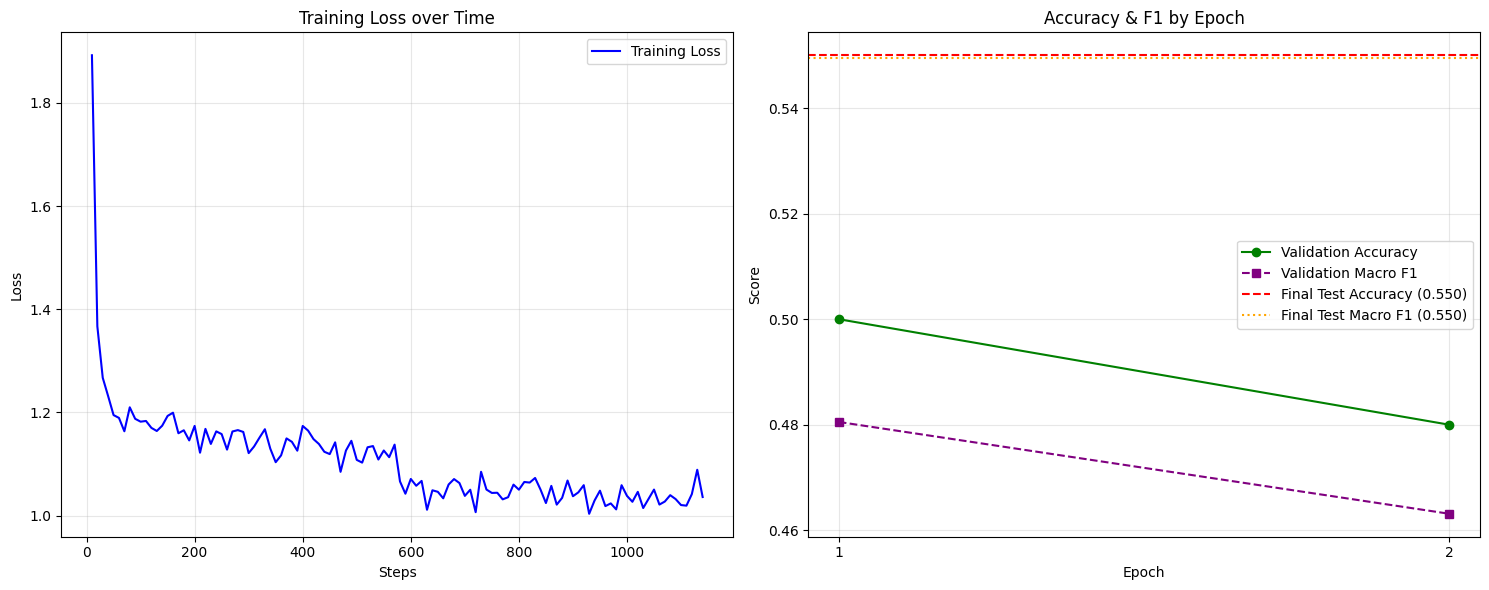

In [20]:
# 2. Plot Training Loss and Validation Metrics
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

val_acc_history = [x['val_accuracy'] for x in history if 'val_accuracy' in x]
val_f1_history = [x.get('val_f1_macro', None) for x in history if 'val_accuracy' in x]
val_f1_history = [v for v in val_f1_history if v is not None]
val_epochs = list(range(1, len(val_acc_history) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Training Loss
ax1.plot(train_steps, train_loss, label='Training Loss', color='blue')
ax1.set_title('Training Loss over Time')
ax1.set_xlabel('Steps')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy & F1 Score
if len(val_acc_history) > 0:
    ax2.plot(val_epochs, val_acc_history, label='Validation Accuracy', color='green', marker='o')
if len(val_f1_history) > 0:
    f1_epochs = list(range(1, len(val_f1_history) + 1))
    ax2.plot(f1_epochs, val_f1_history, label='Validation Macro F1', color='purple', marker='s', linestyle='--')
ax2.axhline(y=acc, color='red', linestyle='--', label=f"Final Test Accuracy ({acc:.3f})")
ax2.axhline(y=f1_mac, color='orange', linestyle=':', label=f"Final Test Macro F1 ({f1_mac:.3f})")
ax2.set_title('Accuracy & F1 by Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Score')
ax2.set_xticks(val_epochs if len(val_epochs) > 0 else [1])
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('qa_gemma_training_curves.png')
plt.show()

Valid predictions: 100/100


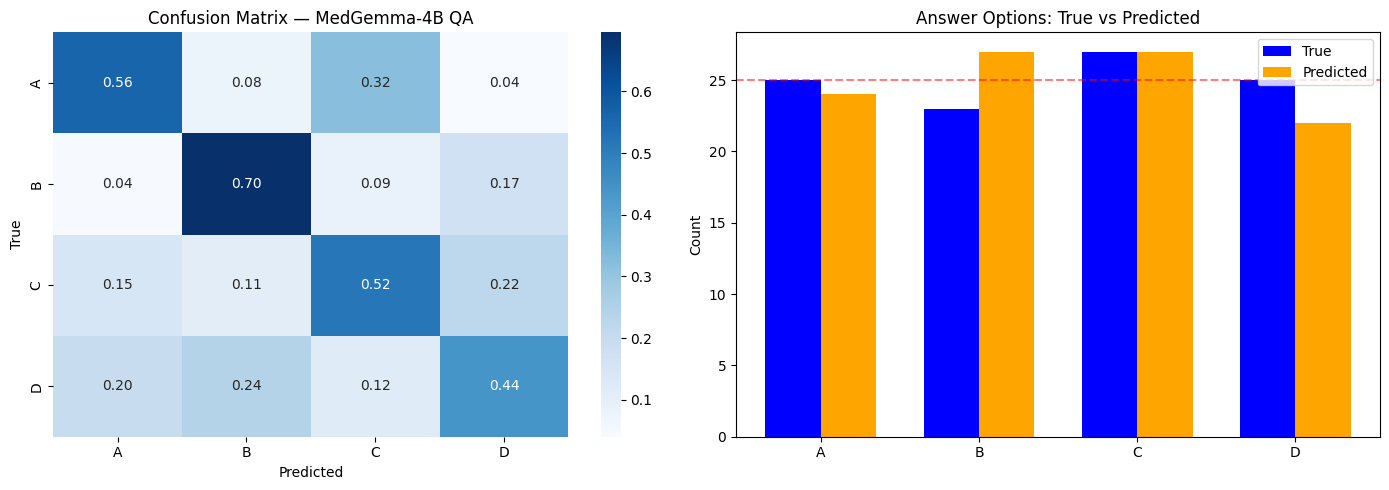

Saved: qa_gemma_confusion_matrix.png

Classification Report (MedGemma-4B):
              precision    recall  f1-score   support

           A       0.58      0.56      0.57        25
           B       0.59      0.70      0.64        23
           C       0.52      0.52      0.52        27
           D       0.50      0.44      0.47        25

    accuracy                           0.55       100
   macro avg       0.55      0.55      0.55       100
weighted avg       0.55      0.55      0.55       100



In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

option_names = ['A', 'B', 'C', 'D']

# Filter out malformed predictions
valid_mask = [p in option_names for p in predictions]
true_valid = [true_labels[i] for i in range(len(true_labels)) if valid_mask[i]]
pred_valid = [predictions[i] for i in range(len(predictions)) if valid_mask[i]]

print(f"Valid predictions: {sum(valid_mask)}/{len(predictions)}")

# 4x4 Confusion Matrix
cm = confusion_matrix(true_valid, pred_valid, labels=option_names, normalize='true')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=option_names, yticklabels=option_names, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix — MedGemma-4B QA')

# Per option prediction frequency
pred_counts = pd.Series(pred_valid).value_counts().reindex(option_names, fill_value=0)
true_counts = pd.Series(true_valid).value_counts().reindex(option_names, fill_value=0)
x = np.arange(len(option_names))
width = 0.35
axes[1].bar(x - width/2, true_counts.values, width, label='True', color='blue')
axes[1].bar(x + width/2, pred_counts.values, width, label='Predicted', color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(option_names)
axes[1].set_ylabel('Count')
axes[1].set_title('Answer Options: True vs Predicted')
axes[1].legend()
axes[1].axhline(y=len(true_valid)/4, color='red', linestyle='--', alpha=0.5) # 25%

plt.tight_layout()
plt.savefig('qa_gemma_confusion_matrix.png')
plt.show()
print("Saved: qa_gemma_confusion_matrix.png")

# Classification report
print("\nClassification Report (MedGemma-4B):")
print(classification_report(true_valid, pred_valid, labels=option_names, zero_division=0))

In [17]:
notebook_end_time = time.time()
elapsed = notebook_end_time - notebook_start_time
hours, rem = divmod(elapsed, 3600)
minutes, seconds = divmod(rem, 60)
print(f"Total notebook execution time: {int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}")


Total notebook execution time: 01:08:25


In [18]:
if PUSH_TO_HUB:
    model.push_to_hub(config.HUB_REPO_ID, token=True)
    tokenizer.push_to_hub(config.HUB_REPO_ID, token=True)

Saved model to https://huggingface.co/alexd063/gemma4bit-finetuned-medqa


No files have been modified since last commit. Skipping to prevent empty commit.
